In [1]:
import collections
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from tqdm.auto import tqdm

from state_pushT.Conditional_Unet1D import ConditionalUnet1D
from state_pushT.pushT_datasets import (
    PushTStateDataset,
    normalize_data,
    unnormalize_data,
)
from state_pushT.pushT_env import PushTEnv

# Environment Setup

In [2]:
# 0. create an instance of the custom PushTEnv environment
env = PushTEnv()

# 1. seed the environment
env.seed(1000)

# 2. must reset the environment before taking any actions
obs, IGNORE_GIT_FOLDER_PATTERNS = env.reset()

In [3]:
# 3. 2D position of the agent
action = env.action_space.sample()
action

array([173.81028693, 214.24559821])

In [4]:
# 4. standard gym step method
obs, reward, terminated, truncated, info = env.step(action)

In [5]:
# prints and explains each dimension of the observation and action vectors
with np.printoptions(precision=4, suppress=True, threshold=5):
    print("Obs: ", repr(obs))
    print("Obs:        [agent_x,  agent_y,  block_x,  block_y,    block_angle]")
    print("Action: ", repr(action))
    print("Action:   [target_agent_x, target_agent_y]")

Obs:  array([147.8838, 148.5701, 292.    , 351.    ,   2.9196])
Obs:        [agent_x,  agent_y,  block_x,  block_y,    block_angle]
Action:  array([173.8103, 214.2456])
Action:   [target_agent_x, target_agent_y]


In [6]:
len(obs), len(action)

(5, 2)

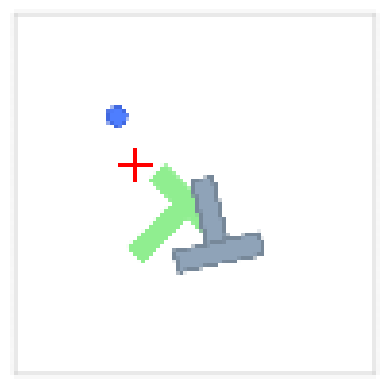

In [7]:
img = env.render(mode="rgb_array")
plt.imshow(img)
plt.axis("off")
plt.show()

# Demo Data Set up

In [8]:
from pathlib import Path

In [9]:
project_root = Path(os.getcwd())
dataset_path = project_root / "state_pushT" / "pusht_cchi_v7_replay.zarr"

In [10]:
# parameters
pred_horizon = 16
obs_horizon = 2
action_horizon = 8
# |o|o|                             observations: 2
# | |a|a|a|a|a|a|a|a|               actions executed: 8
# |p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16

In [11]:
# create dataset from file
dataset = PushTStateDataset(
    dataset_path=dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon,
)
# save training data statistics (min, max) for each dim
stats = dataset.stats

In [12]:
# create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=256,
    num_workers=1,
    shuffle=True,
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=True,
)

# visualize data in batch
batch = next(iter(dataloader))
print("batch['obs'].shape:", batch["obs"].shape)
print("batch['action'].shape", batch["action"].shape)

batch['obs'].shape: torch.Size([256, 2, 5])
batch['action'].shape torch.Size([256, 16, 2])


In [13]:
batch["obs"].shape[0]  # Batch size (B)

256

In [14]:
nobs = batch["obs"]
nobs[:, :obs_horizon, :].shape  # observations

torch.Size([256, 2, 5])

In [15]:
nobs[:, :obs_horizon, :].flatten(start_dim=1).shape  # observations flattened

torch.Size([256, 10])

In [16]:
torch.randn((256, 16, 2)).shape

torch.Size([256, 16, 2])

In [17]:
torch.randint(0, 30000, (256,)).shape

torch.Size([256])

### **Network Demo**


In [18]:
# observation and action dimensions corrsponding to
# the output of PushTEnv
obs_dim = 5
action_dim = 2

# create network object
noise_pred_net = ConditionalUnet1D(
    input_dim=action_dim, global_cond_dim=obs_dim * obs_horizon
)

# example inputs
noised_action = torch.randn((1, pred_horizon, action_dim))
obs = torch.zeros((1, obs_horizon, obs_dim))
diffusion_iter = torch.zeros((1,))

# the noise prediction network
# takes noisy action, diffusion iteration and observation as input
# predicts the noise added to action
noise = noise_pred_net(
    sample=noised_action, timestep=diffusion_iter, global_cond=obs.flatten(start_dim=1)
)

# illustration of removing noise
# the actual noise removal is performed by NoiseScheduler
# and is dependent on the diffusion noise schedule
denoised_action = noised_action - noise

# for this demo, we use DDPMScheduler with 100 diffusion iterations
num_diffusion_iters = 100
noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_diffusion_iters,
    # the choise of beta schedule has big impact on performance
    # we found squared cosine works the best
    beta_schedule="squaredcos_cap_v2",
    # clip output to [-1,1] to improve stability
    clip_sample=True,
    # our network predicts noise (instead of denoised action)
    prediction_type="epsilon",
)

# device transfer
device = torch.device("cuda")
_ = noise_pred_net.to(device)

number of parameters: 6.535322e+07


In [19]:
# load pretrained weights

In [20]:
project_root = Path(os.getcwd())
ckpt_path = project_root / "state_pushT" / "pusht_state_100ep.ckpt"

In [21]:
state_dict = torch.load(ckpt_path, map_location="cuda")
ema_noise_pred_net = noise_pred_net
ema_noise_pred_net.load_state_dict(state_dict)

/tmp/ipykernel_31426/2793465267.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cuda')


<All keys matched successfully>

In [22]:
## inference

In [23]:
from IPython.display import Video
from skvideo.io import vwrite

In [24]:
# limit enviornment interaction to 200 steps before termination
max_steps = 200
env = PushTEnv()
# use a seed >200 to avoid initial states seen in the training dataset
env.seed(100000)

# get first observation
obs, info = env.reset()

# keep a queue of last 2 steps of observations
obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)
# save visualization and rewards
imgs = [env.render(mode="rgb_array")]
rewards = list()
done = False
step_idx = 0

with tqdm(total=max_steps, desc="Eval PushTStateEnv") as pbar:
    while not done:
        B = 1
        # stack the last obs_horizon (2) number of observations
        obs_seq = np.stack(obs_deque)
        # normalize observation
        nobs = normalize_data(obs_seq, stats=stats["obs"])
        # device transfer
        nobs = torch.from_numpy(nobs).to(device, dtype=torch.float32)

        # infer action
        with torch.no_grad():
            # reshape observation to (B,obs_horizon*obs_dim)
            obs_cond = nobs.unsqueeze(0).flatten(start_dim=1)

            # initialize action from Guassian noise
            noisy_action = torch.randn((B, pred_horizon, action_dim), device=device)
            naction = noisy_action

            # init scheduler
            noise_scheduler.set_timesteps(num_diffusion_iters)

            for k in noise_scheduler.timesteps:
                # predict noise
                noise_pred = ema_noise_pred_net(
                    sample=naction, timestep=k, global_cond=obs_cond
                )

                # inverse diffusion step (remove noise)
                naction = noise_scheduler.step(
                    model_output=noise_pred, timestep=k, sample=naction
                ).prev_sample

        # unnormalize action
        naction = naction.detach().to("cpu").numpy()
        # (B, pred_horizon, action_dim)
        naction = naction[0]
        action_pred = unnormalize_data(naction, stats=stats["action"])

        # only take action_horizon number of actions
        start = obs_horizon - 1
        end = start + action_horizon
        action = action_pred[start:end, :]
        # (action_horizon, action_dim)

        # execute action_horizon number of steps
        # without replanning
        for i in range(len(action)):
            # stepping env
            obs, reward, done, _, info = env.step(action[i])
            # save observations
            obs_deque.append(obs)
            # and reward/vis
            rewards.append(reward)
            imgs.append(env.render(mode="rgb_array"))

            # update progress bar
            step_idx += 1
            pbar.update(1)
            pbar.set_postfix(reward=reward)
            if step_idx > max_steps:
                done = True
            if done:
                break

# print out the maximum target coverage
print("Score: ", max(rewards))

# visualize
vwrite("vis.mp4", imgs)
Video("vis.mp4", embed=True, width=256, height=256)

Eval PushTStateEnv:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.9899788844610364
